In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

In [2]:
# -----------------------------
# 1) Synthetic data parameters
# -----------------------------
np.random.seed(42)

n_train = 80
n_test = 1000
p = 50
n_rep = 100

sigma = 1.0

beta_true = np.zeros(p)
beta_true[[0, 5, 10, 15, 20]] = [3.0, -2.5, 2.0, 1.5, -3.5]
beta_0 = 0.0

In [3]:
# -----------------------------
# 2) Data generator
# -----------------------------
def generate_data(n, p, beta_true, beta_0=0.0, sigma=1.0):
    X = np.random.normal(0, 1, size=(n, p))
    eps = np.random.normal(0, sigma, size=n)
    y = beta_0 + X @ beta_true + eps
    return X, y

In [4]:
# -----------------------------
# 3) Fixed test set
# -----------------------------
X_test, y_test = generate_data(n_test, p, beta_true, beta_0, sigma)
f_test = beta_0 + X_test @ beta_true

In [5]:
# -----------------------------
# 4) Lambda grid
# -----------------------------
lambdas = np.logspace(-4, 3, 30)

In [6]:
# -----------------------------
# 5) Containers
# -----------------------------
ridge_bias2 = []
ridge_var = []
ridge_mse = []

lasso_bias2 = []
lasso_var = []
lasso_mse = []

In [7]:
# -----------------------------
# 6) Helper to compute bias/variance/MSE
# -----------------------------
def compute_bias_variance_mse(preds, f_true):
    # preds shape: (n_rep, n_test)
    mean_pred = np.mean(preds, axis=0)
    bias2 = np.mean((mean_pred - f_true) ** 2)
    var = np.mean(np.var(preds, axis=0, ddof=0))
    mse = np.mean(np.mean((preds - f_true[None, :]) ** 2, axis=0))
    return bias2, var, mse


In [8]:
# -----------------------------
# 7) Ridge and Lasso experiments
# -----------------------------
for lam in lambdas:
    ridge_preds = []
    lasso_preds = []

    for _ in range(n_rep):
        X_train, y_train = generate_data(n_train, p, beta_true, beta_0, sigma)

        ridge_model = make_pipeline(
            StandardScaler(),
            Ridge(alpha=lam, fit_intercept=True)
        )
        ridge_model.fit(X_train, y_train)
        ridge_preds.append(ridge_model.predict(X_test))

        lasso_model = make_pipeline(
            StandardScaler(),
            Lasso(alpha=lam, fit_intercept=True, max_iter=10000)
        )
        lasso_model.fit(X_train, y_train)
        lasso_preds.append(lasso_model.predict(X_test))

    ridge_preds = np.array(ridge_preds)
    lasso_preds = np.array(lasso_preds)

    rb2, rv, rm = compute_bias_variance_mse(ridge_preds, f_test)
    lb2, lv, lm = compute_bias_variance_mse(lasso_preds, f_test)

    ridge_bias2.append(rb2)
    ridge_var.append(rv)
    ridge_mse.append(rm)

    lasso_bias2.append(lb2)
    lasso_var.append(lv)
    lasso_mse.append(lm)


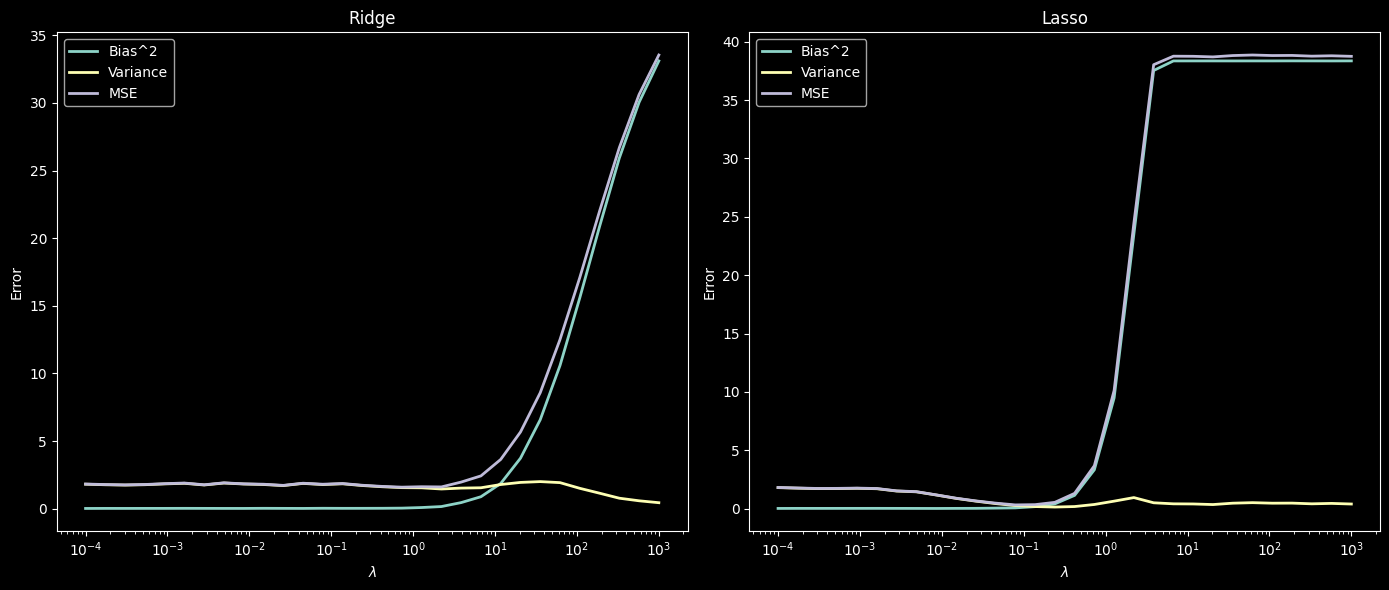

In [9]:
# -----------------------------
# 8) Plot results
# -----------------------------
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(lambdas, ridge_bias2, label="Bias^2", linewidth=2)
plt.plot(lambdas, ridge_var, label="Variance", linewidth=2)
plt.plot(lambdas, ridge_mse, label="MSE", linewidth=2)
plt.xscale("log")
plt.xlabel(r"$\lambda$")
plt.ylabel("Error")
plt.title("Ridge")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(lambdas, lasso_bias2, label="Bias^2", linewidth=2)
plt.plot(lambdas, lasso_var, label="Variance", linewidth=2)
plt.plot(lambdas, lasso_mse, label="MSE", linewidth=2)
plt.xscale("log")
plt.xlabel(r"$\lambda$")
plt.ylabel("Error")
plt.title("Lasso")
plt.legend()

plt.tight_layout()
plt.show()


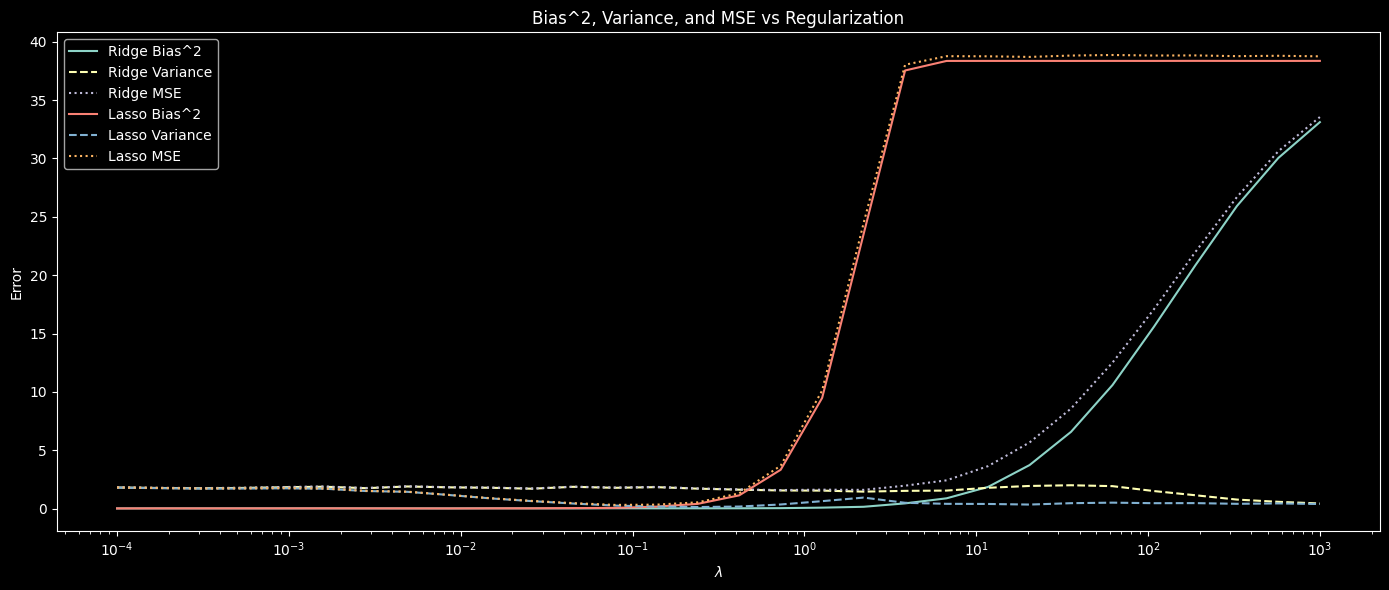

In [10]:
# -----------------------------
# 9) Combined comparison plot
# -----------------------------
plt.figure(figsize=(14, 6))

plt.plot(lambdas, ridge_bias2, label="Ridge Bias^2", linestyle="-")
plt.plot(lambdas, ridge_var, label="Ridge Variance", linestyle="--")
plt.plot(lambdas, ridge_mse, label="Ridge MSE", linestyle=":")

plt.plot(lambdas, lasso_bias2, label="Lasso Bias^2", linestyle="-")
plt.plot(lambdas, lasso_var, label="Lasso Variance", linestyle="--")
plt.plot(lambdas, lasso_mse, label="Lasso MSE", linestyle=":")

plt.xscale("log")
plt.xlabel(r"$\lambda$")
plt.ylabel("Error")
plt.title("Bias^2, Variance, and MSE vs Regularization")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# -----------------------------
# 10) Optional: report best lambda
# -----------------------------
ridge_best_idx = int(np.argmin(ridge_mse))
lasso_best_idx = int(np.argmin(lasso_mse))

print("Ridge best lambda:", lambdas[ridge_best_idx])
print("Ridge best MSE:", ridge_mse[ridge_best_idx])

print("Lasso best lambda:", lambdas[lasso_best_idx])
print("Lasso best MSE:", lasso_mse[lasso_best_idx])


Ridge best lambda: 0.7278953843983154
Ridge best MSE: 1.5861099603376048
Lasso best lambda: 0.07880462815669913
Lasso best MSE: 0.3132861851960814
